# 07 · Mid-term RL state design

For the mid-term, use a **small, explainable discrete state** instead of PCA + k-means.

State = signal-quality context derived from **label-free SNR**:

- State 0: low SNR
- State 1: medium SNR
- State 2: high SNR

The thresholds are calculated using the training recordings only.

This makes the state easy to explain:

> “The agent sees the signal quality context and chooses which wavelet representation to use.”

The full PCA + k-means context design can be restored as an end-sem extension.


In [1]:
%run ../common/00_config.ipynb
use_half("midsem", oracle="classical")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

reward_data = joblib.load(P["processed"] / "midterm_reward_data.joblib")

df = pd.read_csv(P["metadata"] / "records_qc.csv")
df = df.set_index("record_id").loc[reward_data["record_ids"]].reset_index()

train_mask = reward_data["split"] == "train"
snr = df.snr_db.to_numpy(dtype=float)

thresholds = np.quantile(snr[train_mask], [1/3, 2/3])

def make_state(snr_values):
    return np.digitize(snr_values, thresholds, right=False)

state_all = make_state(snr)

state_train = state_all[reward_data["train_idx"]]
state_val = state_all[reward_data["val_idx"]]
state_test = state_all[reward_data["test_idx"]]

print("SNR thresholds:", thresholds)
print("Train state counts:", np.bincount(state_train, minlength=3))


Python environment is working
PyTorch: 2.14.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


CirCor version 1.0.3
midsem: results -> results/midsem/ | reward oracle: classical


SNR thresholds: [20.2252032  24.51811981]
Train state counts: [700 700 700]


## State distribution

In [2]:
state_tab = pd.DataFrame({
    "record_id": reward_data["record_ids"],
    "snr_db": snr,
    "state": state_all,
    "split": reward_data["split"]
})
state_tab.to_csv(P["tables"] / "07_midterm_states.csv", index=False)
state_tab.groupby(["split", "state"]).size()


split  state
test   0        138
       1        156
       2        163
train  0        700
       1        700
       2        700
val    0        148
       1        158
       2        144
dtype: int64

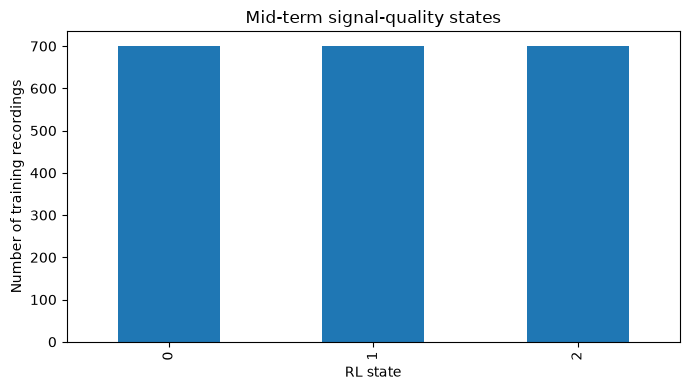

In [3]:
np.savez_compressed(
    P["processed"] / "midterm_states.npz",
    state_train=state_train,
    state_val=state_val,
    state_test=state_test,
    thresholds=thresholds
)

fig, ax = plt.subplots(figsize=(7, 4))
pd.Series(state_train).value_counts().sort_index().plot.bar(ax=ax)
ax.set_xlabel("RL state")
ax.set_ylabel("Number of training recordings")
ax.set_title("Mid-term signal-quality states")
plt.tight_layout()
savefig(fig, "07_midterm_state_distribution")
plt.show()


### RL interpretation

**State** = signal quality context.

The state does not use the murmur label. The label is used only later when the selected action is evaluated and rewarded.
